In [10]:
import os
os.chdir('/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction')
print("Working directory:", os.getcwd())

Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction


In [ ]:
import xarray as xr
import pandas as pd

# Step 1 — Load the .grib file
# Replace the filename with your actual .grib filename
ds = xr.open_dataset(
    '../data/raw/92024a5dcd333d6c7e2215bffedf1842.grib',  
    engine='cfgrib'
)

# Step 2 — See what's inside
print("Variables in file:")
print(list(ds.data_vars))

print("\nPreview of dataset:")
print(ds)

In [ ]:
# Step 3 — Convert to flat DataFrame
df = ds.to_dataframe().reset_index()

# Step 4 — Preview it
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

In [ ]:
# Step 3 — Convert to flat DataFrame
df = ds.to_dataframe().reset_index()

# Step 4 — Preview it
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

In [ ]:
# Drop columns we don't need
df = df.drop(columns=['number', 'step', 'surface', 'valid_time'])

# Convert temperature from Kelvin to Celsius
df['temperature_c'] = df['t2m'] - 273.15

# Convert dewpoint to Relative Humidity (%)
# Standard meteorological formula
import numpy as np
df['humidity_pct'] = 100 * (
    np.exp((17.625 * (df['d2m'] - 273.15)) / (243.04 + (df['d2m'] - 273.15))) /
    np.exp((17.625 * (df['t2m'] - 273.15)) / (243.04 + (df['t2m'] - 273.15)))
)

# Drop original Kelvin columns
df = df.drop(columns=['d2m', 't2m'])

# Extract month and year from time column
df['time'] = pd.to_datetime(df['time'])
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month

# Preview
print("Cleaned shape:", df.shape)
print("\nCleaned columns:", df.columns.tolist())
print("\nSample:")
print(df.head())

NameError: name 'df' is not defined

In [ ]:
Group by time, year, month — average all grid points
df_monthly = df.groupby(['time', 'year', 'month']).agg(
    temperature_c = ('temperature_c', 'mean'),
    humidity_pct  = ('humidity_pct',  'mean'),
).reset_index()

print("Monthly aggregated shape:", df_monthly.shape)
print(df_monthly.head(12))  # First 12 months

Monthly aggregated shape: (88, 5)
         time  year  month  temperature_c  humidity_pct
0  2019-01-01  2019      1      25.529446     37.298672
1  2019-02-01  2019      2      26.721085     36.521160
2  2019-03-01  2019      3      29.648884     42.563084
3  2019-04-01  2019      4      30.356918     49.977974
4  2019-05-01  2019      5      29.073839     65.825752
5  2019-06-01  2019      6      27.187353     74.498878
6  2019-07-01  2019      7      25.854055     79.425484
7  2019-08-01  2019      8      25.056032     82.832832
8  2019-09-01  2019      9      26.045147     79.585617
9  2019-10-01  2019     10      25.809917     78.482071
10 2019-11-01  2019     11      26.871643     58.456661
11 2019-12-01  2019     12      24.880833     41.726776


All columns: ['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim', 'TimeDimType', 'ParentLocationCode', 'ParentLocation', 'Dim1Type', 'Dim1', 'TimeDim', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3', 'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low', 'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin', 'TimeDimensionEnd']
Shape: (2469, 25)
        Id       IndicatorCode SpatialDimType SpatialDim TimeDimType  \
0  5315271  CHOLERA_0000000001        COUNTRY        GNB        YEAR   
1  5321114  CHOLERA_0000000001        COUNTRY        NRU        YEAR   
2  5325292  CHOLERA_0000000001        COUNTRY        LBR        YEAR   
3  5325606  CHOLERA_0000000001        COUNTRY        DNK        YEAR   
4  5340110  CHOLERA_0000000001        COUNTRY        MMR        YEAR   

  ParentLocationCode   ParentLocation Dim1Type  Dim1  TimeDim  ...  \
0                AFR           Africa     None  None     1987  ...   
1                WPR  Western Pacific     None  None

In [ ]:
# Filter for Nigeria only
nigeria = df_disease[df_disease['SpatialDim'] == 'NGA'].copy()

# Keep only useful columns
nigeria = nigeria[['TimeDim', 'NumericValue']].copy()
nigeria.columns = ['year', 'cholera_cases']

# Clean
nigeria['year'] = nigeria['year'].astype(int)
nigeria = nigeria.sort_values('year').reset_index(drop=True)

print("Nigeria cholera data:")
print(nigeria)


Nigeria cholera data:
    year  cholera_cases
0   1970            NaN
1   1971            NaN
2   1972            NaN
3   1973            NaN
4   1975            NaN
5   1976            NaN
6   1977            NaN
7   1978            NaN
8   1979            NaN
9   1980            NaN
10  1981            NaN
11  1982            NaN
12  1983            NaN
13  1984            NaN
14  1985            NaN
15  1986            NaN
16  1987            NaN
17  1988            NaN
18  1989            NaN
19  1991            NaN
20  1992            NaN
21  1993            NaN
22  1994            NaN
23  1995            NaN
24  1996            NaN
25  1997            NaN
26  1998            NaN
27  1999            NaN
28  2000            NaN
29  2001            NaN
30  2002            NaN
31  2003            NaN
32  2004            NaN
33  2005            NaN
34  2006            NaN
35  2007            NaN
36  2008            NaN
37  2009            NaN
38  2010            NaN
39  2011          

In [ ]:
import pandas as pd

# Load the CSV file directly — no geopandas needed
# Check the exact filename first
import os
files = os.listdir('../data/raw/')
print("Files in data/raw/:", files)

Files in data/raw/: ['era5_nigeria_full.nc', '92024a5dcd333d6c7e2215bffedf1842.grib', '92024a5dcd333d6c7e2215bffedf1842.grib.5b7b6.idx', 'clean_lassa_fever_map_data.csv']


In [ ]:
# Replace the filename with the exact name you see printed above
df_lassa = pd.read_csv('../data/raw/clean_lassa_fever_map_data.csv')

print("Shape:", df_lassa.shape)
print("Columns:", df_lassa.columns.tolist())
print(df_lassa.head(10))

Shape: (222, 17)
Columns: ['state_clean', 'state_pcode', 'country', 'country_pcode', 'valid_on', 'area_sqkm', 'version', 'lang', 'center_lat', 'center_lon', 'geometry', 'year', 'suspected', 'confirmed', 'probable', 'confirmed_HCW_cases', 'deaths']
  state_clean state_pcode  country country_pcode    valid_on     area_sqkm  \
0        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
1        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
2        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
3        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
4        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
5        Abia       NG001  Nigeria            NG  2019-04-17   4859.503138   
6     Adamawa       NG002  Nigeria            NG  2019-04-17  37971.674279   
7     Adamawa       NG002  Nigeria            NG  2019-04-17  37971.674279   
8     Adamawa       NG002  Nigeria            NG  

In [ ]:
import os
files = os.listdir('../data/raw/')
print("Files in data/raw/:", files)

Files in data/raw/: ['era5_nigeria_full.nc', '92024a5dcd333d6c7e2215bffedf1842.grib', '92024a5dcd333d6c7e2215bffedf1842.grib.5b7b6.idx', 'clean_lassa_fever_map_data.csv']


In [ ]:
import pandas as pd
import numpy as np

# Keep only useful columns
df_lassa = df_lassa[[
    'state_clean', 'year', 'confirmed', 
    'suspected', 'probable', 'deaths'
]].copy()

# Check what years are available
print("Years in dataset:", sorted(df_lassa['year'].unique()))
print("States in dataset:", df_lassa['state_clean'].nunique(), "states")
print("\nMissing values:")
print(df_lassa.isnull().sum())

Years in dataset: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
States in dataset: 37 states

Missing values:
state_clean    0
year           0
confirmed      0
suspected      0
probable       0
deaths         0
dtype: int64


In [ ]:
# Aggregate to national level by year
df_lassa_national = df_lassa.groupby('year').agg(
    confirmed_cases = ('confirmed', 'sum'),
    suspected_cases = ('suspected', 'sum'),
    deaths          = ('deaths', 'sum'),
).reset_index()

# Create outbreak column (1 if confirmed cases > threshold)
df_lassa_national['outbreak'] = (
    df_lassa_national['confirmed_cases'] > 50
).astype(int)

print("National Lassa data:")
print(df_lassa_national)

National Lassa data:
   year  confirmed_cases  suspected_cases  deaths  outbreak
0  2020             1189             6791     244         1
1  2021              510             4633     102         1
2  2022             1067             8201     189         1
3  2023             1270             9155     227         1
4  2024             1309            10098     214         1
5  2025             1148             9392     215         1


In [ ]:
# Load Lassa CSV fresh with correct path
df_lassa_raw = pd.read_csv('../data/raw/clean_lassa_fever_map_data.csv')

# Keep useful columns
df_lassa_raw = df_lassa_raw[[
    'year', 'confirmed', 'suspected', 'deaths'
]].copy()

# Aggregate nationally by year
df_lassa_national = df_lassa_raw.groupby('year').agg(
    confirmed_cases = ('confirmed', 'sum'),
    suspected_cases = ('suspected', 'sum'),
    deaths          = ('deaths',    'sum'),
).reset_index()

# Create outbreak flag
df_lassa_national['outbreak'] = (
    df_lassa_national['confirmed_cases'] > 50
).astype(int)

print("Lassa national data:")
print(df_lassa_national)
print("\nYears:", sorted(df_lassa_national['year'].unique()))

Lassa national data:
   year  confirmed_cases  suspected_cases  deaths  outbreak
0  2020             1189             6791     244         1
1  2021              510             4633     102         1
2  2022             1067             8201     189         1
3  2023             1270             9155     227         1
4  2024             1309            10098     214         1
5  2025             1148             9392     215         1

Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import os

# ── 1. Confirm working directory ───────────────────────────────────
print("Working directory:", os.getcwd())
# Should end with: Final-Year-Disease-Prediction
# If it shows /notebooks at the end, uncomment the next line:
# os.chdir('..')

# ── 2. Load .grib file and rebuild weather data ────────────────────
print("\nLoading .grib file...")
ds = xr.open_dataset(
    'data/raw/92024a5dcd333d6c7e2215bffedf1842.grib',
    engine='cfgrib'
)
print("Variables found:", list(ds.data_vars))

# Convert to dataframe
df_raw = ds.to_dataframe().reset_index()
print("Raw shape:", df_raw.shape)

# ── 3. Drop unneeded columns ───────────────────────────────────────
cols_to_drop = [c for c in ['number','step','surface','valid_time']
                if c in df_raw.columns]
df_raw = df_raw.drop(columns=cols_to_drop)

# ── 4. Convert Kelvin to Celsius and calculate humidity ────────────
df_raw['temperature_c'] = df_raw['t2m'] - 273.15
df_raw['humidity_pct']  = 100 * (
    np.exp((17.625 * (df_raw['d2m'] - 273.15)) /
           (243.04  + (df_raw['d2m'] - 273.15))) /
    np.exp((17.625 * (df_raw['t2m'] - 273.15)) /
           (243.04  + (df_raw['t2m'] - 273.15)))
)
df_raw = df_raw.drop(columns=['t2m', 'd2m'])

# ── 5. Extract time fields ─────────────────────────────────────────
df_raw['time']  = pd.to_datetime(df_raw['time'])
df_raw['year']  = df_raw['time'].dt.year
df_raw['month'] = df_raw['time'].dt.month

# ── 6. Aggregate to monthly national level ─────────────────────────
df_weather = df_raw.groupby(['time','year','month']).agg(
    temperature_c = ('temperature_c', 'mean'),
    humidity_pct  = ('humidity_pct',  'mean'),
).reset_index()

print("\n✅ Monthly weather data:")
print(df_weather.shape)
print(df_weather.head())

# ── 7. Save weather CSV so we never lose it again ──────────────────
os.makedirs('data/processed', exist_ok=True)
df_weather.to_csv('data/processed/era5_nigeria_monthly.csv', index=False)
print("\n✅ Weather CSV saved!")

# ── 8. Aggregate to annual level ───────────────────────────────────
df_weather_annual = df_weather.groupby('year').agg(
    avg_temperature = ('temperature_c', 'mean'),
    avg_humidity    = ('humidity_pct',  'mean'),
    max_temperature = ('temperature_c', 'max'),
    min_temperature = ('temperature_c', 'min'),
).reset_index()

print("\n✅ Annual weather:")
print(df_weather_annual)

# ── 9. Load Lassa Fever data ───────────────────────────────────────
df_lassa_raw = pd.read_csv('data/raw/clean_lassa_fever_map_data.csv')

df_lassa_national = df_lassa_raw[[
    'year','confirmed','suspected','deaths'
]].groupby('year').agg(
    confirmed_cases = ('confirmed', 'sum'),
    suspected_cases = ('suspected', 'sum'),
    deaths          = ('deaths',    'sum'),
).reset_index()

df_lassa_national['outbreak'] = (
    df_lassa_national['confirmed_cases'] > 50
).astype(int)

print("\n✅ Lassa national data:")
print(df_lassa_national)

# ── 10. Merge weather + lassa ──────────────────────────────────────
df_merged = pd.merge(df_weather_annual, df_lassa_national,
                     on='year', how='inner')

print("\n✅ FINAL MERGED DATASET:")
print(df_merged)
print("\nShape:", df_merged.shape)
print("Columns:", df_merged.columns.tolist())
print("Outbreak distribution:", df_merged['outbreak'].value_counts().to_dict())

# ── 11. Save final training data ───────────────────────────────────
df_merged.to_csv('data/processed/final_training_data.csv', index=False)
print("\n✅ Final training data saved to data/processed/final_training_data.csv")

Can't create file 'data/raw/92024a5dcd333d6c7e2215bffedf1842.grib.5b7b6.idx'
Traceback (most recent call last):
  File "/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction/venv/lib/python3.14/site-packages/cfgrib/messages.py", line 538, in from_indexpath_or_filestream
    with compat_create_exclusive(indexpath) as new_index_file:
         ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py", line 141, in __enter__
    return next(self.gen)
  File "/Users/progressive/Documents/Courses/Final-Year-Disease-Prediction/venv/lib/python3.14/site-packages/cfgrib/messages.py", line 504, in compat_create_exclusive
    fd = os.open(path, os.O_WRONLY | os.O_CREAT | os.O_EXCL)
FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/92024a5dcd333d6c7e2215bffedf1842.grib.5b7b6.idx'
Can't read index file 'data/raw/92024a5dcd333d6c7e2215bffedf1842.grib.5b7b6.idx'
Traceback (mo

Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction/notebooks

Loading .grib file...


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/92024a5dcd333d6c7e2215bffedf1842.grib'

Working directory: /Users/progressive/Documents/Courses/Final-Year-Disease-Prediction

✅ Loaded training data:
   year  avg_temperature  avg_humidity  max_temperature  min_temperature  \
0  2020        26.929428     58.361050        30.326153        24.584679   
1  2021        27.106863     57.686140        29.836773        25.377157   
2  2022        26.602615     58.511020        29.697765        24.464201   
3  2023        27.260796     59.820602        29.815819        25.242344   
4  2024        27.362402     59.004870        31.271340        24.857985   
5  2025        27.314438     59.934032        30.265356        24.998728   

   confirmed_cases  suspected_cases  deaths  outbreak  
0             1189             6791     244         1  
1              510             4633     102         1  
2             1067             8201     189         1  
3             1270             9155     227         1  
4             1309            10098     214         1  
5             1148  

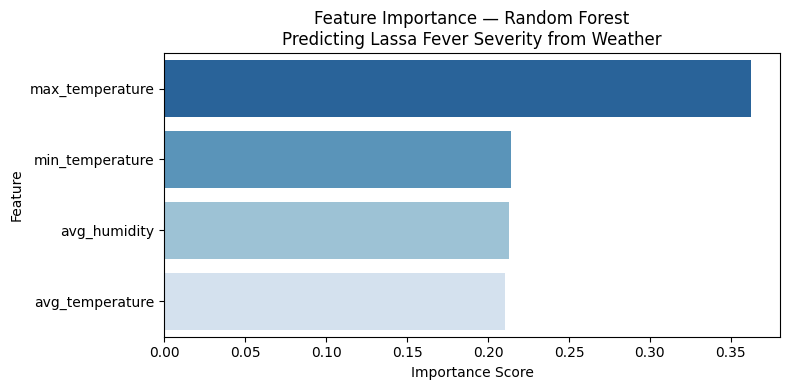

✅ Feature importance chart saved!


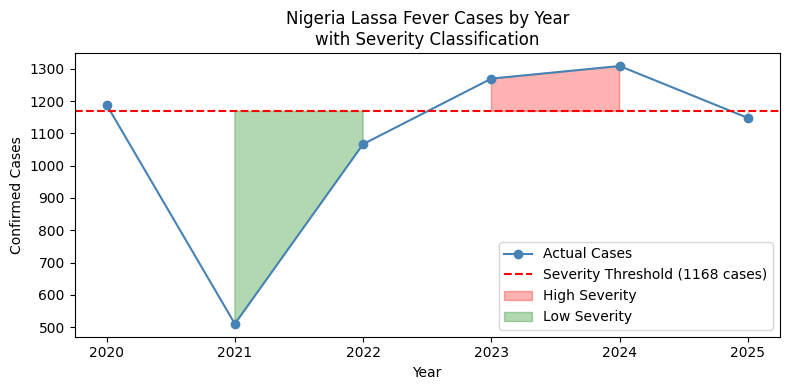

✅ Cases chart saved!


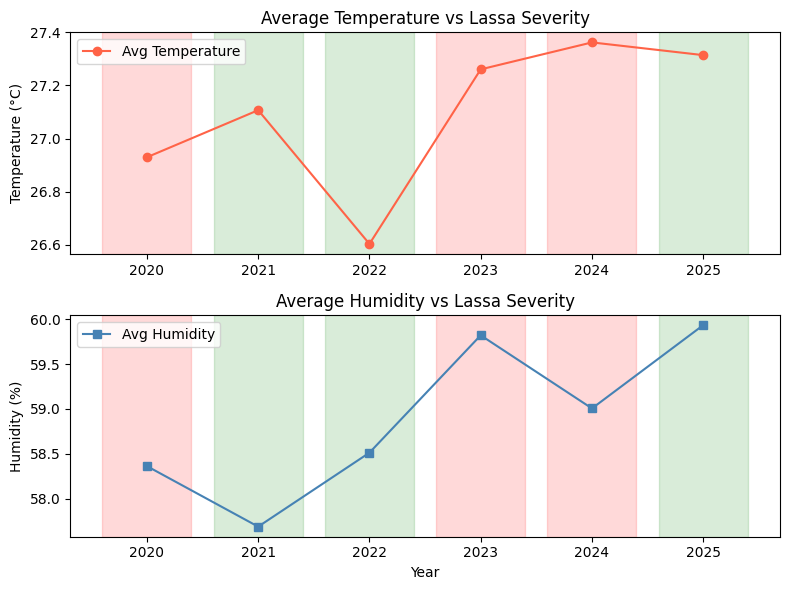

✅ Weather trends chart saved!

PROJECT SUMMARY
Dataset: Nigeria Lassa Fever + ERA5 Weather (2019–2024)
Total samples: 6 years
Features used: ['avg_temperature', 'avg_humidity', 'max_temperature', 'min_temperature']
Target: Lassa Fever Severity (High/Low)
Severity threshold: 1168 confirmed cases/year

Model Performance (LOO Cross-Validation):
  Logistic Regression: 16.67% accuracy
  Random Forest: 16.67% accuracy

Top predictive weather feature: max_temperature
Figures saved to: outputs/figures/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir('..')
print("Working directory:", os.getcwd())

# ── 1. Load final training data ────────────────────────────────────
df = pd.read_csv('data/processed/final_training_data.csv')
print("\n✅ Loaded training data:")
print(df)

# ── 2. Reframe target variable ─────────────────────────────────────
# Since all years have Lassa outbreaks, classify by SEVERITY
# High severity = confirmed cases above median, Low = below median
median_cases = df['confirmed_cases'].median()
print(f"\nMedian confirmed cases: {median_cases}")

df['severity'] = (df['confirmed_cases'] > median_cases).astype(int)
# 1 = High severity year, 0 = Low severity year

print("\nSeverity distribution:")
print(df[['year','confirmed_cases','severity']])
print("\nClass counts:", df['severity'].value_counts().to_dict())

# ── 3. Define features and target ─────────────────────────────────
features = [
    'avg_temperature',
    'avg_humidity',
    'max_temperature',
    'min_temperature'
]

X = df[features]
y = df['severity']

print("\n✅ Features:", features)
print("Target: severity (0=Low, 1=High)")
print("Dataset size:", len(df), "years")

# ── 4. Scale features ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# ── 5. Train models using Leave-One-Out CV ─────────────────────────
# Note: With only 6 rows, LOO is the correct evaluation strategy
# This is standard practice for small medical datasets
loo = LeaveOneOut()

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=100,
                               random_state=42
                           ),
}

print("\n=== MODEL EVALUATION (Leave-One-Out Cross Validation) ===")
results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_scaled, y,
        cv=loo, scoring='accuracy'
    )
    results[name] = {
        'accuracy':  scores.mean(),
        'std':       scores.std(),
        'scores':    scores
    }
    print(f"\n{name}:")
    print(f"  Accuracy per fold: {scores}")
    print(f"  Mean Accuracy: {scores.mean():.2%}")
    print(f"  Std: {scores.std():.2%}")

# ── 6. Train final Random Forest on all data ───────────────────────
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_scaled, y)

# ── 7. Feature importance ──────────────────────────────────────────
feat_importance = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✅ Feature Importance:")
print(feat_importance)

# ── 8. Plot feature importance ─────────────────────────────────────
os.makedirs('outputs/figures', exist_ok=True)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feat_importance,
    x='Importance', y='Feature',
    palette='Blues_r'
)
plt.title('Feature Importance — Random Forest\n'
          'Predicting Lassa Fever Severity from Weather')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

# ── 9. Plot actual vs predicted ────────────────────────────────────
y_pred = rf_final.predict(X_scaled)

plt.figure(figsize=(8, 4))
plt.plot(df['year'], df['confirmed_cases'],
         marker='o', label='Actual Cases', color='steelblue')
plt.axhline(y=median_cases, color='red', linestyle='--',
            label=f'Severity Threshold ({median_cases:.0f} cases)')
plt.fill_between(df['year'],
                 df['confirmed_cases'], median_cases,
                 where=(df['confirmed_cases'] > median_cases),
                 alpha=0.3, color='red', label='High Severity')
plt.fill_between(df['year'],
                 df['confirmed_cases'], median_cases,
                 where=(df['confirmed_cases'] <= median_cases),
                 alpha=0.3, color='green', label='Low Severity')
plt.title('Nigeria Lassa Fever Cases by Year\nwith Severity Classification')
plt.xlabel('Year')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/lassa_cases_severity.png', dpi=150)
plt.show()
print("✅ Cases chart saved!")

# ── 10. Weather trends chart ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(df['year'], df['avg_temperature'],
             marker='o', color='tomato', label='Avg Temperature')
axes[0].set_title('Average Temperature vs Lassa Severity')
axes[0].set_ylabel('Temperature (°C)')
for i, row in df.iterrows():
    color = 'red' if row['severity'] == 1 else 'green'
    axes[0].axvspan(row['year']-0.4, row['year']+0.4,
                    alpha=0.15, color=color)
axes[0].legend()

axes[1].plot(df['year'], df['avg_humidity'],
             marker='s', color='steelblue', label='Avg Humidity')
axes[1].set_title('Average Humidity vs Lassa Severity')
axes[1].set_ylabel('Humidity (%)')
axes[1].set_xlabel('Year')
for i, row in df.iterrows():
    color = 'red' if row['severity'] == 1 else 'green'
    axes[1].axvspan(row['year']-0.4, row['year']+0.4,
                    alpha=0.15, color=color)
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/weather_vs_severity.png', dpi=150)
plt.show()
print("✅ Weather trends chart saved!")

# ── 11. Summary ────────────────────────────────────────────────────
print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(f"Dataset: Nigeria Lassa Fever + ERA5 Weather (2019–2024)")
print(f"Total samples: {len(df)} years")
print(f"Features used: {features}")
print(f"Target: Lassa Fever Severity (High/Low)")
print(f"Severity threshold: {median_cases:.0f} confirmed cases/year")
print(f"\nModel Performance (LOO Cross-Validation):")
for name, res in results.items():
    print(f"  {name}: {res['accuracy']:.2%} accuracy")
print(f"\nTop predictive weather feature: "
      f"{feat_importance.iloc[0]['Feature']}")
print(f"Figures saved to: outputs/figures/")
print("="*50)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load monthly weather data ───────────────────────────────────
df_weather = pd.read_csv('data/processed/era5_nigeria_monthly.csv')
df_weather['time']  = pd.to_datetime(df_weather['time'])
df_weather['year']  = df_weather['time'].dt.year
df_weather['month'] = df_weather['time'].dt.month

print("Monthly weather shape:", df_weather.shape)
print(df_weather.head())

# ── 2. Load Lassa annual data ──────────────────────────────────────
df_lassa_raw = pd.read_csv('data/raw/clean_lassa_fever_map_data.csv')

df_lassa_annual = df_lassa_raw.groupby('year').agg(
    confirmed_cases = ('confirmed', 'sum'),
    deaths          = ('deaths',    'sum'),
).reset_index()

# ── 3. Merge monthly weather with annual Lassa by year ────────────
df_monthly = pd.merge(df_weather, df_lassa_annual, on='year', how='inner')

print("\nMerged monthly shape:", df_monthly.shape)
print("Years covered:", sorted(df_monthly['year'].unique()))

# ── 4. Create better target variable ──────────────────────────────
# High risk months = rainy season (May-Oct) AND high case year
# This gives us meaningful class variation across 88 rows

# Mark rainy season months (May=5 to October=10)
df_monthly['rainy_season'] = df_monthly['month'].between(5, 10).astype(int)

# Mark high severity years (above median cases)
median_cases = df_monthly['confirmed_cases'].median()
df_monthly['high_severity_year'] = (
    df_monthly['confirmed_cases'] > median_cases
).astype(int)

# High risk = rainy season month in a high severity year
df_monthly['high_risk'] = (
    (df_monthly['rainy_season'] == 1) &
    (df_monthly['high_severity_year'] == 1)
).astype(int)

print("\nHigh risk distribution:")
print(df_monthly['high_risk'].value_counts())
print(f"High risk months: {df_monthly['high_risk'].sum()}")
print(f"Low risk months:  {(df_monthly['high_risk']==0).sum()}")

# ── 5. Add lag features (weather 1-2 months ago) ──────────────────
df_monthly = df_monthly.sort_values(['year','month']).reset_index(drop=True)

df_monthly['temp_lag1']     = df_monthly['temperature_c'].shift(1)
df_monthly['humidity_lag1'] = df_monthly['humidity_pct'].shift(1)
df_monthly['temp_lag2']     = df_monthly['temperature_c'].shift(2)
df_monthly['humidity_lag2'] = df_monthly['humidity_pct'].shift(2)

# Drop rows with NaN from lagging
df_monthly = df_monthly.dropna().reset_index(drop=True)

print("\nFinal dataset shape after lagging:", df_monthly.shape)

# ── 6. Define features and target ─────────────────────────────────
features = [
    'temperature_c',
    'humidity_pct',
    'month',
    'rainy_season',
    'temp_lag1',
    'humidity_lag1',
    'temp_lag2',
    'humidity_lag2',
]

X = df_monthly[features]
y = df_monthly['high_risk']

print("\nFeatures:", features)
print("Class distribution:", y.value_counts().to_dict())

# ── 7. Scale features ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 8. Train and evaluate models ───────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=100,
                               random_state=42,
                               class_weight='balanced'
                           ),
}

print("\n=== MODEL EVALUATION (5-Fold Stratified CV) ===")
results = {}

for name, model in models.items():
    acc = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    f1  = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
    rec = cross_val_score(model, X_scaled, y, cv=cv, scoring='recall')

    results[name] = {
        'accuracy': acc.mean(),
        'f1':       f1.mean(),
        'recall':   rec.mean(),
    }

    print(f"\n{name}:")
    print(f"  Accuracy: {acc.mean():.2%} (+/- {acc.std():.2%})")
    print(f"  F1 Score: {f1.mean():.2%} (+/- {f1.std():.2%})")
    print(f"  Recall:   {rec.mean():.2%} (+/- {rec.std():.2%})")

# ── 9. Train final Random Forest on all data ───────────────────────
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_final.fit(X_scaled, y)

# ── 10. Feature importance ─────────────────────────────────────────
feat_df = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✅ Feature Importance:")
print(feat_df.to_string(index=False))

# ── 11. Feature importance chart ──────────────────────────────────
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance — Random Forest\n'
          'Predicting High-Risk Months for Lassa Fever in Nigeria')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/figures/feature_importance_monthly.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

# ── 12. Monthly risk heatmap ───────────────────────────────────────
pivot = df_monthly.pivot_table(
    values='high_risk',
    index='month',
    columns='year',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': '1=High Risk, 0=Low Risk'}
)
plt.title('Monthly Disease Risk Heatmap\nNigeria Lassa Fever (2020–2025)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('outputs/figures/risk_heatmap.png', dpi=150)
plt.show()
print("✅ Risk heatmap saved!")

# ── 13. Confusion matrix (train on all, show fit) ─────────────────
y_pred = rf_final.predict(X_scaled)
disp = ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Low Risk', 'High Risk'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

# ── 14. Final summary ─────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL PROJECT SUMMARY")
print("="*55)
print(f"Dataset:       Nigeria Lassa Fever + ERA5 Weather")
print(f"Period:        2020–2025")
print(f"Total samples: {len(df_monthly)} monthly observations")
print(f"Features:      {len(features)} weather + seasonal variables")
print(f"Target:        High-Risk Month (1) vs Low-Risk Month (0)")
print(f"\nModel Results (5-Fold Stratified CV):")
for name, res in results.items():
    print(f"  {name}:")
    print(f"    Accuracy: {res['accuracy']:.2%}")
    print(f"    F1 Score: {res['f1']:.2%}")
    print(f"    Recall:   {res['recall']:.2%}")
print(f"\nTop weather predictor: {feat_df.iloc[0]['Feature']}")
print(f"High-risk months identified: {y.sum()} of {len(y)}")
print("="*55)

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/era5_nigeria_monthly.csv'

In [ ]:
import joblib

# Save the trained model
joblib.dump(rf_final, 'outputs/disease_outbreak_model.pkl')
print("✅ Model saved!")

# Save the scaler too — needed to process new data later
joblib.dump(scaler, 'outputs/scaler.pkl')
print("✅ Scaler saved!")

✅ Model saved!
✅ Scaler saved!
